This is the final model architecture which will be build and it is substantially different from a regular CNN. Here we will make use of Vision transformers, this makes it better at recognizing global patterns in the image and should (hopefully) provide a good performance boost.

The first model which will be tested is on a small DeiT which is distilled during pretraining (the weights basically have some numbers removed from them in order to make the entire model smaller). It will at first only be a trained head on top of this pretrained model to see if it can perform, afterwards we will move onto either using a larger ViT or unfreeze more layers to train on more layers of the pretrained ViT.

Prerequisits

In [ ]:
!pip install -q keras-hub huggingface_hub

In [ ]:
from huggingface_hub import notebook_login
notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Libraries needed

In [ ]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import keras_hub

from pathlib import Path
from tensorflow import keras
from tensorflow.keras import layers
from huggingface_hub import create_repo, upload_folder

Paths + creation of dataset

In [ ]:
DATASET_DIR = Path("/content/drive/MyDrive/Speciale/dataset/nutrition5k_compactV3")

# Metadata CSV
METADATA_CSV = Path("/content/drive/MyDrive/Speciale/dataset/prepared_overhead_rgb_dataset/dish_carb_split_metadata.csv")

# Output folder for this model
OUTPUT_DIR = Path("/content/drive/MyDrive/Speciale/Models/Model_3_ViT_rgb")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
df = pd.read_csv(METADATA_CSV)

print(df.head())
print(df["split"].value_counts())

           dish_id  total_carb split source_cafe
0  dish_1556575327      10.618  test       cafe1
1  dish_1557861216       0.000  test       cafe1
2  dish_1557862345       0.000  test       cafe1
3  dish_1557862696       3.850  test       cafe1
4  dish_1557862738       0.000  test       cafe1
split
train    2421
test      507
val       334
Name: count, dtype: int64


In [ ]:
df["image_path"] = df["dish_id"].apply(
    lambda d: str(DATASET_DIR / d / "overhead" / "rgb.png")
)

df["image_exists"] = df["image_path"].apply(lambda p: Path(p).exists())

print("Missing images:", (~df["image_exists"]).sum())

df = df[df["image_exists"]].copy()

print(df["split"].value_counts())
print(df.head())

Missing images: 0
split
train    2421
test      507
val       334
Name: count, dtype: int64
           dish_id  total_carb split source_cafe  \
0  dish_1556575327      10.618  test       cafe1   
1  dish_1557861216       0.000  test       cafe1   
2  dish_1557862345       0.000  test       cafe1   
3  dish_1557862696       3.850  test       cafe1   
4  dish_1557862738       0.000  test       cafe1   

                                          image_path  image_exists  
0  /content/drive/MyDrive/Speciale/dataset/nutrit...          True  
1  /content/drive/MyDrive/Speciale/dataset/nutrit...          True  
2  /content/drive/MyDrive/Speciale/dataset/nutrit...          True  
3  /content/drive/MyDrive/Speciale/dataset/nutrit...          True  
4  /content/drive/MyDrive/Speciale/dataset/nutrit...          True  


In [ ]:
train_df = df[df["split"] == "train"].copy()
val_df   = df[df["split"] == "val"].copy()
test_df  = df[df["split"] == "test"].copy()

print("Train:", len(train_df))
print("Val:  ", len(val_df))
print("Test: ", len(test_df))

Train: 2421
Val:   334
Test:  507


In [ ]:
IMG_HEIGHT = 224
IMG_WIDTH  = 224
BATCH_SIZE = 16
AUTOTUNE   = tf.data.AUTOTUNE
EPOCHS     = 200

VIT_PRESET = "deit_small_distilled_patch16_224_imagenet"

The image size has been altered here unlike with the other models due to the pretrained ViT working only with these size of images. It doesnt change a whole lot, just that the images contains less information than they would in their original format.

In [ ]:
def load_image_and_label(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, [IMG_HEIGHT, IMG_WIDTH])
    image = tf.cast(image, tf.float32)   # keep in [0,255]
    label = tf.cast(label, tf.float32)
    return image, label


def make_dataset(dataframe, batch_size=8, shuffle=False):
    image_paths = dataframe["image_path"].values
    labels = dataframe["total_carb"].values.astype("float32")

    ds = tf.data.Dataset.from_tensor_slices((image_paths, labels))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=42)

    ds = ds.map(load_image_and_label, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds


train_dataset = make_dataset(train_df, batch_size=BATCH_SIZE, shuffle=True)
validation_dataset = make_dataset(val_df, batch_size=BATCH_SIZE, shuffle=False)
test_dataset = make_dataset(test_df, batch_size=BATCH_SIZE, shuffle=False)

Model architecture

In [ ]:
# Preprocessing layer matched to the DeiT preset
image_converter = keras_hub.layers.ImageConverter.from_preset(VIT_PRESET)

# Pretrained DeiT backbone
backbone = keras_hub.models.Backbone.from_preset(VIT_PRESET)

# First stage: freeze pretrained backbone
backbone.trainable = False

inputs = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3), name="rgb_input")

# Preset-specific preprocessing
x = image_converter(inputs)

# Forward pass through pretrained transformer backbone
x = backbone(x)

if isinstance(x, dict):
    if "sequence_output" in x:
        x = x["sequence_output"]
    else:
        x = list(x.values())[0]

# Pool token sequence into a single feature vector for regression
x = layers.GlobalAveragePooling1D(name="token_avg_pool")(x)
x = layers.Dropout(0.3, name="dropout")(x)
x = layers.Dense(256, activation="relu", name="dense_256")(x)
x = layers.Dropout(0.2, name="dropout_2")(x)
outputs = layers.Dense(1, activation="linear", name="carb_output")(x)

model = keras.Model(inputs, outputs, name="deit_small_rgb_pretrained_carb_regression")
model.summary()

100%|██████████| 616/616 [00:00<00:00, 1.28MB/s]


100%|██████████| 968/968 [00:00<00:00, 1.71MB/s]


Model: "deit_small_rgb_pretrained_carb_regression"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rgb_input (InputLayer)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dei_t_image_converter           │ (None, 224, 224, 3)    │             0 │
│ (DeiTImageConverter)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dei_t_backbone (DeiTBackbone)   │ (None, 198, 384)       │    21,666,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_avg_pool                  │ (None, 384)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ carb_output (Dense)             │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,765,249 (83.03 MB)

 Trainable params: 98,817 (386.00 KB)

 Non-trainable params: 21,666,432 (82.65 MB)

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.MeanSquaredError(name="mse")
    ],
    jit_compile=False # Disable JIT compilation to avoid XLA compatibility issues
)

In [ ]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(OUTPUT_DIR / "best_model.keras"),
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=100,
        mode="min",
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=75,
        min_lr=1e-6,
        mode="min",
        verbose=1
    )
]

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/200
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 804.4445 - mae: 13.9309 - mse: 804.4445
Epoch 1: val_loss improved from None to 161.63992, saving model to /content/drive/MyDrive/Speciale/Models/Model_3_ViT_rgb/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Speciale/Models/Model_3_ViT_rgb/best_model.keras
152/152 ━━━━━━━━━━━━━━━━━━━━ 192s 1s/step - loss: 513.1115 - mae: 12.1210 - mse: 513.1115 - val_loss: 161.6399 - val_mae: 10.0420 - val_mse: 161.6399 - learning_rate: 0.0010
Epoch 2/200
150/152 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 542.1600 - mae: 10.4135 - mse: 542.1600
Epoch 2: val_loss improved from 161.63992 to 146.24683, saving model to /content/drive/MyDrive/Speciale/Models/Model_3_ViT_rgb/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Speciale/Models/Model_3_ViT_rgb/best_model.keras
152/152 ━━━━━━━━━━━━━━━━━━━━ 9s 58ms/step - loss: 447.7872 - mae: 10.1615 - mse: 447.7872 - val_loss: 146.2468 - val_mae: 9.885

Plotting

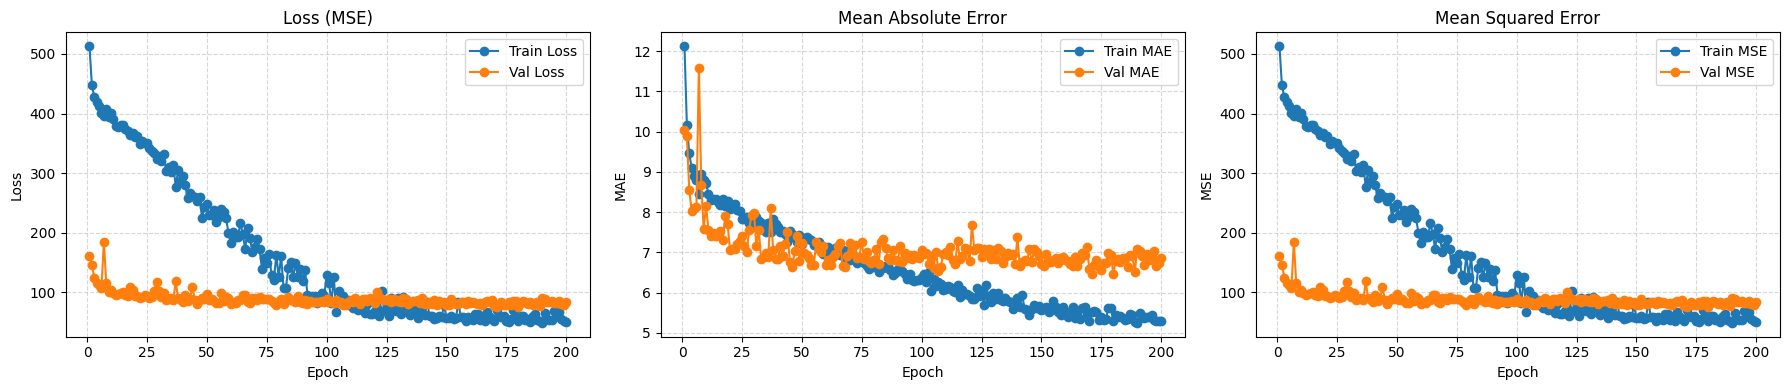

Best val_loss: 74.6531 at epoch 171
Val MAE at best epoch: 6.4532
Val MSE at best epoch: 74.6531


In [ ]:
def plot_metrics(history):
    h = history.history
    epochs = np.arange(1, len(h["loss"]) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    axes[0].plot(epochs, h["loss"], marker="o", label="Train Loss")
    axes[0].plot(epochs, h["val_loss"], marker="o", label="Val Loss")
    axes[0].set_title("Loss (MSE)")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True, linestyle="--", alpha=0.5)

    if "mae" in h and "val_mae" in h:
        axes[1].plot(epochs, h["mae"], marker="o", label="Train MAE")
        axes[1].plot(epochs, h["val_mae"], marker="o", label="Val MAE")
        axes[1].set_title("Mean Absolute Error")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("MAE")
        axes[1].legend()
        axes[1].grid(True, linestyle="--", alpha=0.5)

    if "mse" in h and "val_mse" in h:
        axes[2].plot(epochs, h["mse"], marker="o", label="Train MSE")
        axes[2].plot(epochs, h["val_mse"], marker="o", label="Val MSE")
        axes[2].set_title("Mean Squared Error")
        axes[2].set_xlabel("Epoch")
        axes[2].set_ylabel("MSE")
        axes[2].legend()
        axes[2].grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

    best = np.argmin(h["val_loss"])
    print(f"Best val_loss: {h['val_loss'][best]:.4f} at epoch {best + 1}")

    if "val_mae" in h:
        print(f"Val MAE at best epoch: {h['val_mae'][best]:.4f}")
    if "val_mse" in h:
        print(f"Val MSE at best epoch: {h['val_mse'][best]:.4f}")


plot_metrics(history)

Evaluation on test set

In [ ]:
loaded_model = tf.keras.models.load_model(str(OUTPUT_DIR / "best_model.keras"))

In [ ]:
loaded_model_test_results = loaded_model.evaluate(test_dataset, return_dict=True)
print(loaded_model_test_results)

In [ ]:
test_results = model.evaluate(test_dataset, return_dict=True)
print(test_results)

32/32 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - loss: 105.2667 - mae: 7.3433 - mse: 105.2667
{'loss': 105.26671600341797, 'mae': 7.343265533447266, 'mse': 105.26671600341797}


**Stage 2**

This stage is if the model performs alright on stage 1 where only a regression head has been added. In this stage 2 the last 25% of the backbone of the pretrained model will become unfrozen and the model will therefor begin to adjust the weights of that for our specific dataset. That is the only change happening and if training is stable enough and performance improves we could unfreeze more layers.

Loading best stage 1 model

In [ ]:
stage1_model_path = OUTPUT_DIR / "best_model.keras"
model = keras.models.load_model(stage1_model_path)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 408 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "deit_small_rgb_pretrained_carb_regression"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rgb_input (InputLayer)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dei_t_image_converter           │ (None, 224, 224, 3)    │             0 │
│ (DeiTImageConverter)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dei_t_backbone (DeiTBackbone)   │ (None, 198, 384)       │    21,666,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_avg_pool                  │ (None, 384)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ carb_output (Dense)             │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,295,749 (249.08 MB)

 Trainable params: 21,765,249 (83.03 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 43,530,500 (166.06 MB)

The following code block let us expect the ViT backbone a bit more closely

In [ ]:
for i, layer in enumerate(model.layers):
    print(i, layer.name, layer.__class__.__name__, layer.trainable)

0 rgb_input InputLayer True
1 dei_t_image_converter DeiTImageConverter True
2 dei_t_backbone DeiTBackbone False
3 token_avg_pool GlobalAveragePooling1D True
4 dropout Dropout True
5 dense_256 Dense True
6 dropout_2 Dropout True
7 carb_output Dense True


Unfreezing last 25% of ViT backbone

In [ ]:
# Find the nested backbone model
backbone = None
for layer in model.layers:
    if isinstance(layer, keras.Model) and layer.name != model.name:
        backbone = layer
        break

if backbone is None:
    raise ValueError("Could not locate the pretrained ViT backbone inside the model.")

print("Backbone found:", backbone.name)
print("Number of backbone layers:", len(backbone.layers))

Backbone found: dei_t_backbone
Number of backbone layers: 3


In [ ]:
# Unfreeze only the later part of the backbone
backbone.trainable = True

num_backbone_layers = len(backbone.layers)
unfreeze_from = int(num_backbone_layers * 0.75)   # last 25%

for i, layer in enumerate(backbone.layers):
    layer.trainable = i >= unfreeze_from

print(f"Unfreezing backbone layers from index {unfreeze_from} to {num_backbone_layers - 1}")
print("Trainable backbone layers:", sum(layer.trainable for layer in backbone.layers))

Unfreezing backbone layers from index 2 to 2
Trainable backbone layers: 1


In [ ]:
model.summary()

print("Trainable weights:", len(model.trainable_weights))
print("Non-trainable weights:", len(model.non_trainable_weights))

Model: "deit_small_rgb_pretrained_carb_regression"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rgb_input (InputLayer)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dei_t_image_converter           │ (None, 224, 224, 3)    │             0 │
│ (DeiTImageConverter)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dei_t_backbone (DeiTBackbone)   │ (None, 198, 384)       │    21,666,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_avg_pool                  │ (None, 384)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ carb_output (Dense)             │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,295,749 (249.08 MB)

 Trainable params: 21,393,153 (81.61 MB)

 Non-trainable params: 372,096 (1.42 MB)

 Optimizer params: 43,530,500 (166.06 MB)

Trainable weights: 198
Non-trainable weights: 5


Recompile and callbacks for stage 2

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="mse",
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.MeanSquaredError(name="mse")
    ],
    jit_compile=False # Disable JIT compilation to avoid XLA compatibility issues
)

In [ ]:
stage2_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(OUTPUT_DIR / "best_model_stage2.keras"),
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=100,
        mode="min",
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=75,
        min_lr=1e-7,
        mode="min",
        verbose=1
    )
]

In [ ]:
history_stage2 = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=200,
    callbacks=stage2_callbacks
)

Epoch 1/200
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 94.8326 - mae: 5.5107 - mse: 94.8326
Epoch 1: val_loss improved from None to 81.22993, saving model to /content/drive/MyDrive/Speciale/Models/Model_3_ViT_rgb/best_model_stage2.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Speciale/Models/Model_3_ViT_rgb/best_model_stage2.keras
152/152 ━━━━━━━━━━━━━━━━━━━━ 45s 98ms/step - loss: 152.7356 - mae: 6.0317 - mse: 152.7356 - val_loss: 81.2299 - val_mae: 6.9868 - val_mse: 81.2299 - learning_rate: 1.0000e-05
Epoch 2/200
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 121.8835 - mae: 7.0374 - mse: 121.8835
Epoch 2: val_loss did not improve from 81.22993
152/152 ━━━━━━━━━━━━━━━━━━━━ 12s 76ms/step - loss: 354.9060 - mae: 6.9549 - mse: 354.9060 - val_loss: 83.4758 - val_mae: 7.0612 - val_mse: 83.4758 - learning_rate: 1.0000e-05
Epoch 3/200
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 76.8275 - mae: 5.7882 - mse: 76.8275
Epoch 3: val_loss did not improve from 81.22

Plotting stage 2

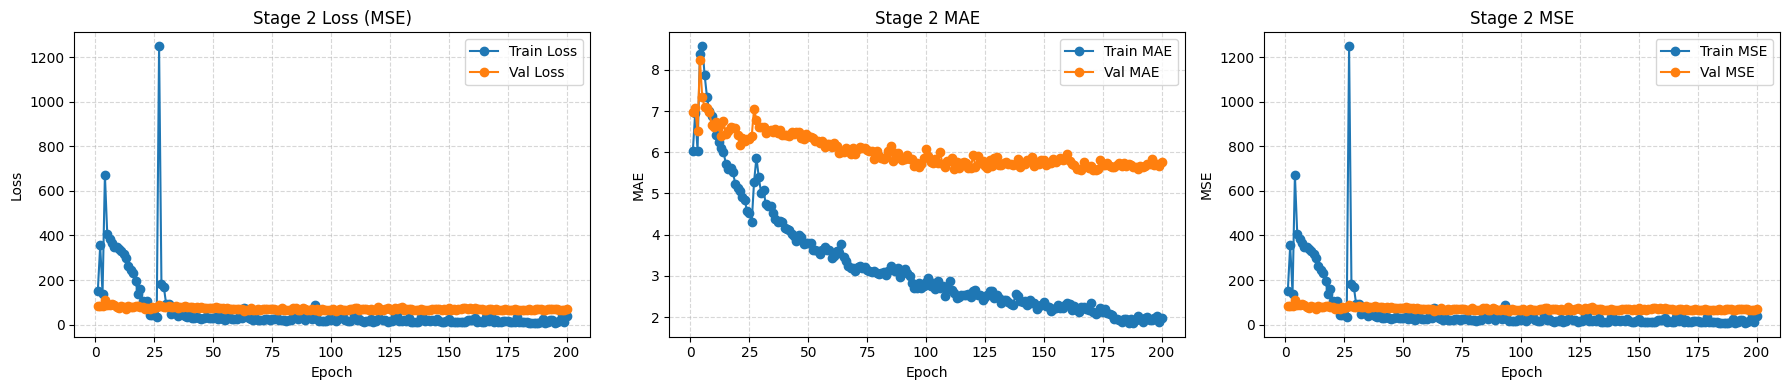

In [ ]:
def plot_metrics(history, title_prefix=""):
    h = history.history
    epochs = np.arange(1, len(h["loss"]) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    axes[0].plot(epochs, h["loss"], marker="o", label="Train Loss")
    axes[0].plot(epochs, h["val_loss"], marker="o", label="Val Loss")
    axes[0].set_title(f"{title_prefix} Loss (MSE)")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True, linestyle="--", alpha=0.5)

    if "mae" in h and "val_mae" in h:
        axes[1].plot(epochs, h["mae"], marker="o", label="Train MAE")
        axes[1].plot(epochs, h["val_mae"], marker="o", label="Val MAE")
        axes[1].set_title(f"{title_prefix} MAE")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("MAE")
        axes[1].legend()
        axes[1].grid(True, linestyle="--", alpha=0.5)

    if "mse" in h and "val_mse" in h:
        axes[2].plot(epochs, h["mse"], marker="o", label="Train MSE")
        axes[2].plot(epochs, h["val_mse"], marker="o", label="Val MSE")
        axes[2].set_title(f"{title_prefix} MSE")
        axes[2].set_xlabel("Epoch")
        axes[2].set_ylabel("MSE")
        axes[2].legend()
        axes[2].grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

plot_metrics(history_stage2, title_prefix="Stage 2")

Evaluating stage 2 on test set

In [ ]:
best_stage2_model = keras.models.load_model(OUTPUT_DIR / "best_model_stage2.keras")
stage2_test_results = best_stage2_model.evaluate(test_dataset, return_dict=True)
print(stage2_test_results)

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 408 variables whereas the saved optimizer has 398 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 73.1745 - mae: 6.0149 - mse: 73.1745
{'loss': 73.1745376586914, 'mae': 6.014938831329346, 'mse': 73.1745376586914}
